**生成式 AI 使用说明**：在本课程作业中，使用生成式 AI 需要遵守与协作讨论相同的政策。和其他合作者一样，每位学生都必须独立写出自己的解答，不能直接依赖交互输出完成提交内容，并且提交时应说明协作的性质。使用生成式 AI 工具实质性地完成作业中的部分内容，不符合本课程作业精神，也会违反 [Honor Code](https://communitystandards.stanford.edu/policies-and-guidance/honor-code)。

In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment1/'
FOLDERNAME = 'cs231n/assignments/assignment1/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
!bash get_datasets.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

# 全连接神经网络
在本练习中，我们将采用模块化方法实现全连接网络。对于每一层，我们都会实现一个 `forward` 函数和一个 `backward` 函数。`forward` 函数接收输入、权重和其他参数，并返回输出以及一个保存反向传播所需数据的 `cache` 对象，如下所示：

```python
def layer_forward(x, w):
  """接收输入 x 和权重 w"""
  # 执行一些计算……
  z = # ……某个中间值
  # 再执行一些计算……
  out = # 输出
   
  cache = (x, w, z, out) # 计算梯度所需的值
   
  return out, cache
```

反向传播接收上游梯度和 `cache` 对象，并返回损失相对于输入和权重的梯度，如下所示：

```python
def layer_backward(dout, cache):
  """
  接收 dout（损失对输出的导数）和 cache，
  并计算损失对输入的导数。
  """
  # 解包 cache 中的值
  x, w, z, out = cache
  
  # 使用 cache 中的值计算导数
  dx = # 损失对 x 的导数
  dw = # 损失对 w 的导数
  
  return dx, dw
```

以这种方式实现多个层之后，我们就可以轻松地组合它们，构建具有不同架构的分类器。
  

In [14]:
# As usual, a bit of setup
from __future__ import print_function
import time
import numpy as np
import matplotlib.pyplot as plt
from cs231n.classifiers.fc_net import *
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.solver import Solver

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

def rel_error(x, y):
  """ returns relative error """
  return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# Load the (preprocessed) CIFAR10 data.

data = get_CIFAR10_data()
for k, v in list(data.items()):
  print(('%s: ' % k, v.shape))

('X_train: ', (49000, 3, 32, 32))
('y_train: ', (49000,))
('X_val: ', (1000, 3, 32, 32))
('y_val: ', (1000,))
('X_test: ', (1000, 3, 32, 32))
('y_test: ', (1000,))


# 仿射层：前向传播
打开 `cs231n/layers.py` 文件并实现 `affine_forward` 函数。

完成后，可以运行下面的代码测试你的实现：

In [3]:
# Test the affine_forward function

num_inputs = 2
input_shape = (4, 5, 6)
output_dim = 3

input_size = num_inputs * np.prod(input_shape)
weight_size = output_dim * np.prod(input_shape)

x = np.linspace(-0.1, 0.5, num=input_size).reshape(num_inputs, *input_shape)
w = np.linspace(-0.2, 0.3, num=weight_size).reshape(np.prod(input_shape), output_dim)
b = np.linspace(-0.3, 0.1, num=output_dim)

out, _ = affine_forward(x, w, b)
correct_out = np.array([[ 1.49834967,  1.70660132,  1.91485297],
                        [ 3.25553199,  3.5141327,   3.77273342]])

# Compare your output with ours. The error should be around e-9 or less.
print('Testing affine_forward function:')
print('difference: ', rel_error(out, correct_out))

Testing affine_forward function:
difference:  9.769848888397517e-10


# 仿射层：反向传播
现在实现 `affine_backward` 函数，并使用数值梯度检查测试你的实现。

In [4]:
# Test the affine_backward function
np.random.seed(231)
x = np.random.randn(10, 2, 3)
w = np.random.randn(6, 5)
b = np.random.randn(5)
dout = np.random.randn(10, 5)

dx_num = eval_numerical_gradient_array(lambda x: affine_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_forward(x, w, b)[0], b, dout)

_, cache = affine_forward(x, w, b)
dx, dw, db = affine_backward(dout, cache)

# The error should be around e-10 or less
print('Testing affine_backward function:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

Testing affine_backward function:
dx error:  1.0908199508708189e-10
dw error:  2.1752635504596857e-10
db error:  7.736978834487815e-12


# ReLU 激活：前向传播
在 `relu_forward` 函数中实现 ReLU 激活函数的前向传播，然后使用下面的代码测试你的实现：

In [6]:
# Test the relu_forward function

x = np.linspace(-0.5, 0.5, num=12).reshape(3, 4)

out, _ = relu_forward(x)
correct_out = np.array([[ 0.,          0.,          0.,          0.,        ],
                        [ 0.,          0.,          0.04545455,  0.13636364,],
                        [ 0.22727273,  0.31818182,  0.40909091,  0.5,       ]])

# Compare your output with ours. The error should be on the order of e-8
print('Testing relu_forward function:')
print('difference: ', rel_error(out, correct_out))

Testing relu_forward function:
difference:  4.999999798022158e-08


# ReLU 激活：反向传播
现在在 `relu_backward` 函数中实现 ReLU 激活函数的反向传播，并使用数值梯度检查测试你的实现：

In [8]:
np.random.seed(231)
x = np.random.randn(10, 10)
dout = np.random.randn(*x.shape)

dx_num = eval_numerical_gradient_array(lambda x: relu_forward(x)[0], x, dout)

_, cache = relu_forward(x)
dx = relu_backward(dout, cache)

# The error should be on the order of e-12
print('Testing relu_backward function:')
print('dx error: ', rel_error(dx_num, dx))

Testing relu_backward function:
dx error:  3.2756349136310288e-12


## 行内问题 1：

我们只要求你实现 ReLU，但神经网络还可以使用许多不同的激活函数，它们各有优缺点。激活函数的一个常见问题是：反向传播时梯度变为零或接近零。下面哪些激活函数存在这个问题？如果只考虑一维情况，哪些类型的输入会导致这种现象？
1. Sigmoid
2. ReLU
3. Leaky ReLU

$\color{blue}{\textit{你的答案：}}$ *在此填写*




# “三明治”层
神经网络中经常会使用一些常见的层组合模式。例如，仿射层后面通常会接一个 ReLU 非线性激活。为了方便使用这些常见模式，我们在 `cs231n/layer_utils.py` 文件中定义了几个便捷的组合层。

现在先查看 `affine_relu_forward` 和 `affine_relu_backward` 函数，然后运行下面的代码，对反向传播进行数值梯度检查：

In [13]:
from cs231n.layer_utils import affine_relu_forward, affine_relu_backward
np.random.seed(231)
x = np.random.randn(2, 3, 4)
w = np.random.randn(12, 10)
b = np.random.randn(10)
dout = np.random.randn(2, 10)

out, cache = affine_relu_forward(x, w, b)
dx, dw, db = affine_relu_backward(dout, cache)

dx_num = eval_numerical_gradient_array(lambda x: affine_relu_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_relu_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_relu_forward(x, w, b)[0], b, dout)

# Relative error should be around e-10 or less
print('Testing affine_relu_forward and affine_relu_backward:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

Testing affine_relu_forward and affine_relu_backward:
dx error:  6.395535042049294e-11
dw error:  8.162015570444288e-11
db error:  7.826724021458994e-12


# 损失层：Softmax
现在，在 `cs231n/layers.py` 的 `softmax_loss` 函数中实现 Softmax 的损失和梯度。它们应当与你在 `cs231n/classifiers/softmax.py` 中的实现类似。其他损失函数（例如 `svm_loss`）也可以用模块化方式实现，但本次作业不作要求。

可以运行下面的代码确认实现是否正确：

In [4]:
np.random.seed(231)
num_classes, num_inputs = 10, 50
x = 0.001 * np.random.randn(num_inputs, num_classes)
y = np.random.randint(num_classes, size=num_inputs)


dx_num = eval_numerical_gradient(lambda x: softmax_loss(x, y)[0], x, verbose=False)
loss, dx = softmax_loss(x, y)

# Test softmax_loss function. Loss should be close to 2.3 and dx error should be around e-8
print('\nTesting softmax_loss:')
print('loss: ', loss)
print('dx error: ', rel_error(dx_num, dx))


Testing softmax_loss:
loss:  2.3025458445007376
dx error:  8.234144091578429e-09


# 两层网络
打开 `cs231n/classifiers/fc_net.py` 文件，完成 `TwoLayerNet` 类的实现。通读该类，确保你理解其 API。可以运行下面的单元格测试你的实现。

In [ ]:
np.random.seed(231)
N, D, H, C = 3, 5, 50, 7
X = np.random.randn(N, D)
y = np.random.randint(C, size=N)

std = 1e-3
model = TwoLayerNet(input_dim=D, hidden_dim=H, num_classes=C, weight_scale=std)

print('Testing initialization ... ')
W1_std = abs(model.params['W1'].std() - std)
b1 = model.params['b1']
W2_std = abs(model.params['W2'].std() - std)
b2 = model.params['b2']
assert W1_std < std / 10, 'First layer weights do not seem right'
assert np.all(b1 == 0), 'First layer biases do not seem right'
assert W2_std < std / 10, 'Second layer weights do not seem right'
assert np.all(b2 == 0), 'Second layer biases do not seem right'

print('Testing test-time forward pass ... ')
model.params['W1'] = np.linspace(-0.7, 0.3, num=D*H).reshape(D, H)
model.params['b1'] = np.linspace(-0.1, 0.9, num=H)
model.params['W2'] = np.linspace(-0.3, 0.4, num=H*C).reshape(H, C)
model.params['b2'] = np.linspace(-0.9, 0.1, num=C)
X = np.linspace(-5.5, 4.5, num=N*D).reshape(D, N).T
scores = model.loss(X)
correct_scores = np.asarray(
  [[11.53165108,  12.2917344,   13.05181771,  13.81190102,  14.57198434, 15.33206765,  16.09215096],
   [12.05769098,  12.74614105,  13.43459113,  14.1230412,   14.81149128, 15.49994135,  16.18839143],
   [12.58373087,  13.20054771,  13.81736455,  14.43418138,  15.05099822, 15.66781506,  16.2846319 ]])
scores_diff = np.abs(scores - correct_scores).sum()
assert scores_diff < 1e-6, 'Problem with test-time forward pass'

print('Testing training loss (no regularization)')
y = np.asarray([0, 5, 1])
loss, grads = model.loss(X, y)
correct_loss = 3.4702243556
assert abs(loss - correct_loss) < 1e-10, 'Problem with training-time loss'

model.reg = 1.0
loss, grads = model.loss(X, y)
correct_loss = 26.5948426952
assert abs(loss - correct_loss) < 1e-10, 'Problem with regularization loss'

# Errors should be around e-7 or less
for reg in [0.0, 0.7]:
  print('Running numeric gradient check with reg = ', reg)
  model.reg = reg
  loss, grads = model.loss(X, y)

  for name in sorted(grads):
    f = lambda _: model.loss(X, y)[0]
    grad_num = eval_numerical_gradient(f, model.params[name], verbose=False)
    print('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))

Testing initialization ... 
Testing test-time forward pass ... 
Testing training loss (no regularization)
Running numeric gradient check with reg =  0.0
W1 relative error: 1.83e-08
W2 relative error: 3.37e-10
b1 relative error: 8.01e-09
b2 relative error: 2.53e-10
Running numeric gradient check with reg =  0.7
W1 relative error: 2.53e-07
W2 relative error: 2.85e-08
b1 relative error: 1.35e-08
b2 relative error: 1.97e-09


: 

# Solver
打开 `cs231n/solver.py` 文件并通读内容，熟悉其 API。之后，使用一个 `Solver` 实例训练 `TwoLayerNet`，使其在验证集上的准确率达到约 `36%`。

In [6]:
input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10
model = TwoLayerNet(input_size, hidden_size, num_classes)
solver = None

##############################################################################
# TODO: Use a Solver instance to train a TwoLayerNet that achieves about 36% #
# accuracy on the validation set.                                            #
##############################################################################

solver=Solver(model,data,update_rule="sgd",
              optim_config={"learning_rate": 1e-4,},
              lr_decay=0.95,
              num_epochs=5,
              batch_size=200,print_every=100,
              )
solver.train()
print(solver.val_acc_history)
##############################################################################
#                             END OF YOUR CODE                               #
##############################################################################

(Iteration 1 / 1225) loss: 2.299918
(Epoch 0 / 5) train acc: 0.124000; val_acc: 0.161000
(Iteration 101 / 1225) loss: 2.242939
(Iteration 201 / 1225) loss: 2.127856
(Epoch 1 / 5) train acc: 0.224000; val_acc: 0.252000
(Iteration 301 / 1225) loss: 2.035697
(Iteration 401 / 1225) loss: 2.023281
(Epoch 2 / 5) train acc: 0.291000; val_acc: 0.298000
(Iteration 501 / 1225) loss: 1.958135
(Iteration 601 / 1225) loss: 1.952775
(Iteration 701 / 1225) loss: 1.889645
(Epoch 3 / 5) train acc: 0.316000; val_acc: 0.321000
(Iteration 801 / 1225) loss: 1.811423
(Iteration 901 / 1225) loss: 1.795963
(Epoch 4 / 5) train acc: 0.351000; val_acc: 0.352000
(Iteration 1001 / 1225) loss: 1.857102
(Iteration 1101 / 1225) loss: 1.659162
(Iteration 1201 / 1225) loss: 1.742913
(Epoch 5 / 5) train acc: 0.353000; val_acc: 0.375000
[0.161, 0.252, 0.298, 0.321, 0.352, 0.375]


# 调试训练过程
使用上面提供的默认参数时，验证集准确率应该约为 0.36，效果并不好。

一种排查问题的方式，是绘制优化过程中损失函数以及训练集、验证集准确率的变化曲线。

另一种方式，是可视化网络第一层学到的权重。对于大多数在视觉数据上训练的神经网络，第一层权重在可视化后通常会呈现出一些可辨认的结构。

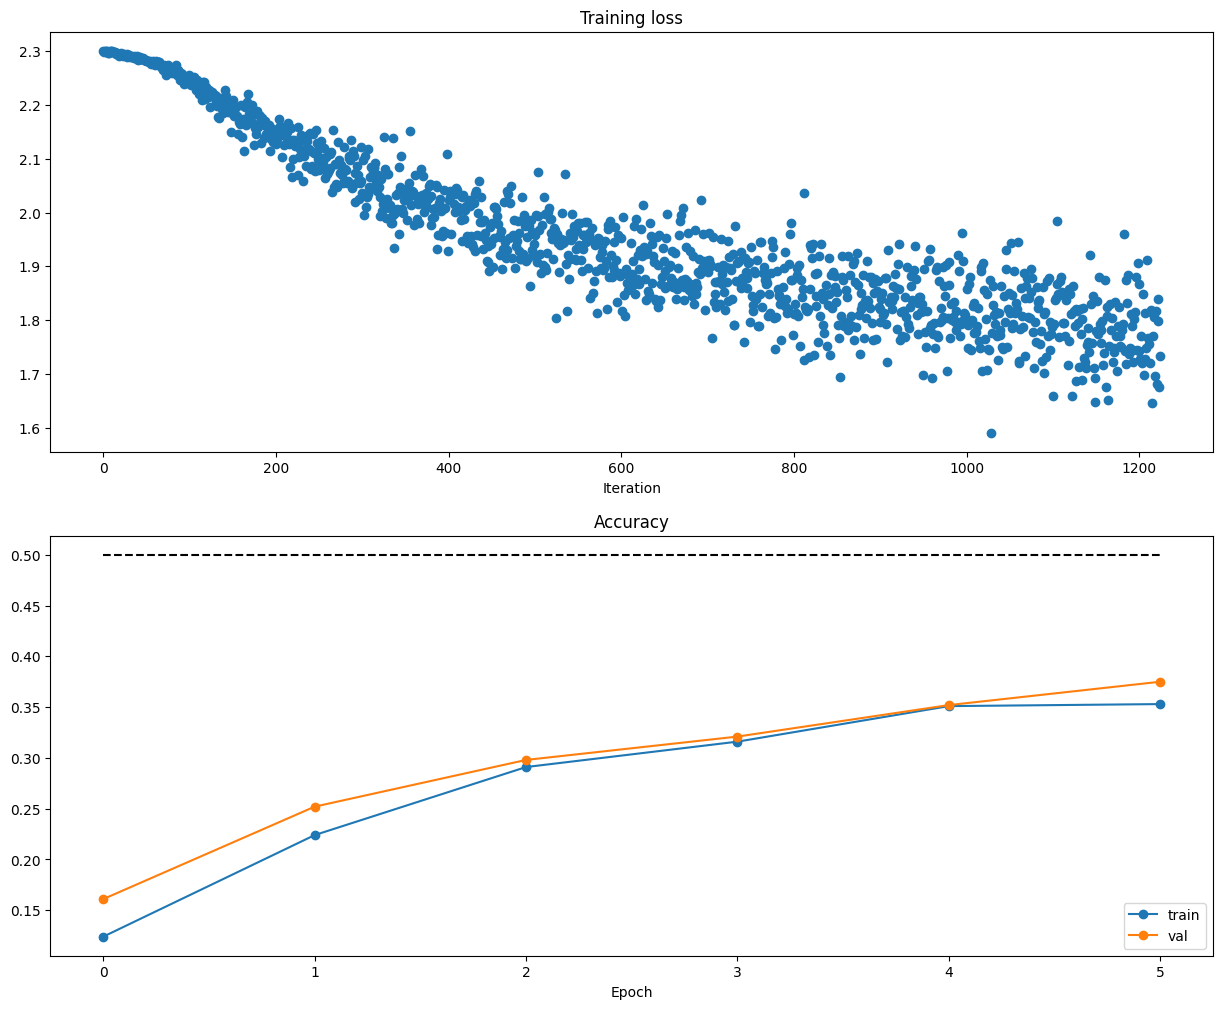

In [7]:
# Run this cell to visualize training loss and train / val accuracy

plt.subplot(2, 1, 1)
plt.title('Training loss')
plt.plot(solver.loss_history, 'o')
plt.xlabel('Iteration')

plt.subplot(2, 1, 2)
plt.title('Accuracy')
plt.plot(solver.train_acc_history, '-o', label='train')
plt.plot(solver.val_acc_history, '-o', label='val')
plt.plot([0.5] * len(solver.val_acc_history), 'k--')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.gcf().set_size_inches(15, 12)
plt.show()

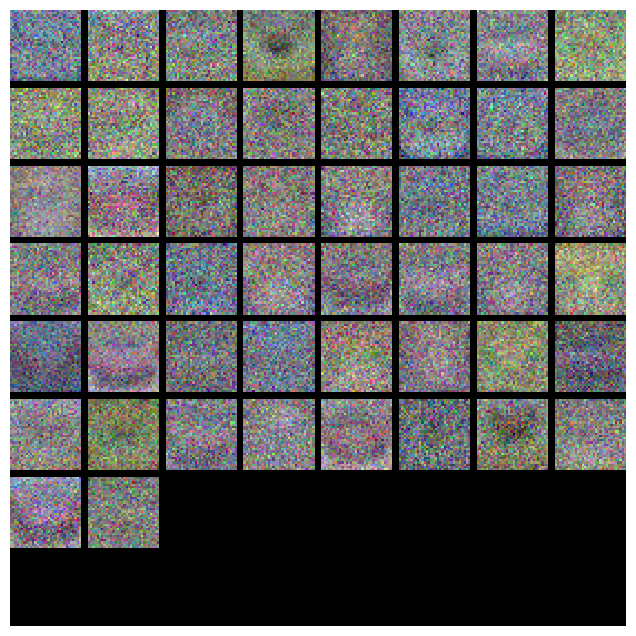

In [8]:
from cs231n.vis_utils import visualize_grid

# Visualize the weights of the network

def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(3, 32, 32, -1).transpose(3, 1, 2, 0)
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()

show_net_weights(model)

# 调整超参数

**问题出在哪里？**观察上面的可视化结果，可以看到损失大致呈线性下降，这似乎说明学习率可能过低。此外，训练准确率与验证准确率之间没有明显差距，说明当前模型容量较低，应当增大模型规模。另一方面，如果模型非常大，我们预计会看到更明显的过拟合，表现为训练准确率与验证准确率之间出现很大的差距。

**调参。**调整超参数并建立对它们如何影响最终性能的直觉，是使用神经网络时非常重要的一部分，因此我们希望你充分练习。下面请尝试各种超参数取值，包括隐藏层大小、学习率、训练 epoch 数和正则化强度。你也可以考虑调整学习率衰减，但使用默认值应该已经能够取得不错的效果。

**预期结果。**你的目标应是在验证集上达到 48% 以上的分类准确率。我们的最佳网络在验证集上超过了 52%。

**实验目标：**本练习的目标是使用全连接神经网络，在 CIFAR-10 上取得尽可能好的结果（52% 可作为参考）。你可以自由实现自己的方法，例如使用 PCA 降维、加入 Dropout，或为 Solver 添加其他功能等。

In [17]:
best_model = None



#################################################################################
# TODO: Tune hyperparameters using the validation set. Store your best trained  #
# model in best_model.                                                          #
#                                                                               #
# To help debug your network, it may help to use visualizations similar to the  #
# ones we used above; these visualizations will have significant qualitative    #
# differences from the ones we saw above for the poorly tuned network.          #
#                                                                               #
# Tweaking hyperparameters by hand can be fun, but you might find it useful to  #
# write code to sweep through possible combinations of hyperparameters          #
# automatically like we did on thexs previous exercises.                          #
#################################################################################
lr=[1e-4,1e-3]
ne=[5,10]
hs=[50,75,100]
Greatest=[0,0,0,0]
best_model=None
best_solver=None
print("Begin trainning:")

for learning_rate in lr:
    for num_epochs in ne:
        for hidden_size in hs:
            print(f"learning_rate is {learning_rate} num_epochs is{num_epochs} hidden_size is {hidden_size}")
            model=TwoLayerNet(input_size, hidden_size, num_classes)
            solver=Solver(model,data,update_rule="sgd",
              optim_config={"learning_rate": learning_rate,},
              lr_decay=0.95,
              num_epochs=num_epochs,
              batch_size=200,print_every=100,
              )
            solver.train()
            print(solver.val_acc_history)
            if solver.val_acc_history[num_epochs]>Greatest[0]:
                Greatest[0]=solver.val_acc_history[num_epochs]
                Greatest[1]=learning_rate
                Greatest[2]=num_epochs
                Greatest[3]=hidden_size
                best_model=model
                best_solver=solver
            print("OVER")
print(f"The best val_accuracy if {Greatest[0]},its learning_rate is {Greatest[1]} the num_epochs is {Greatest[2]} the hidden_size is {Greatest[3]}")


################################################################################
#                              END OF YOUR CODE                                #
################################################################################

Begin trainning:
learning_rate is 0.0001 num_epochs is5 hidden_size is 50
(Iteration 1 / 1225) loss: 2.300227
(Epoch 0 / 5) train acc: 0.109000; val_acc: 0.099000
(Iteration 101 / 1225) loss: 2.251138
(Iteration 201 / 1225) loss: 2.114893
(Epoch 1 / 5) train acc: 0.237000; val_acc: 0.246000
(Iteration 301 / 1225) loss: 2.002332
(Iteration 401 / 1225) loss: 2.046913
(Epoch 2 / 5) train acc: 0.292000; val_acc: 0.297000
(Iteration 501 / 1225) loss: 2.011020
(Iteration 601 / 1225) loss: 1.938836
(Iteration 701 / 1225) loss: 1.917127
(Epoch 3 / 5) train acc: 0.345000; val_acc: 0.329000
(Iteration 801 / 1225) loss: 1.871428
(Iteration 901 / 1225) loss: 1.875095
(Epoch 4 / 5) train acc: 0.354000; val_acc: 0.360000
(Iteration 1001 / 1225) loss: 1.809867
(Iteration 1101 / 1225) loss: 1.705190
(Iteration 1201 / 1225) loss: 1.676281
(Epoch 5 / 5) train acc: 0.358000; val_acc: 0.377000
[0.099, 0.246, 0.297, 0.329, 0.36, 0.377]
OVER
learning_rate is 0.0001 num_epochs is5 hidden_size is 75
(Iteratio

(Iteration 1 / 4900) loss: 2.307846
(Epoch 0 / 20) train acc: 0.197000; val_acc: 0.194000


c:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment1\cs231n\layers.py:725: RuntimeWarning: divide by zero encountered in log
  loss =-np.mean(np.log(correct))


(Iteration 101 / 4900) loss: inf
(Iteration 201 / 4900) loss: inf
(Epoch 1 / 20) train acc: 0.106000; val_acc: 0.094000
(Iteration 301 / 4900) loss: inf


c:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment1\cs231n\layers.py:31: RuntimeWarning: overflow encountered in matmul
  out=x_flatten@w+b
c:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment1\cs231n\layers.py:722: RuntimeWarning: overflow encountered in subtract
  scores = x-np.max(x,axis=1,keepdims=True)
c:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment1\cs231n\layers.py:722: RuntimeWarning: invalid value encountered in subtract
  scores = x-np.max(x,axis=1,keepdims=True)


(Iteration 401 / 4900) loss: nan
(Epoch 2 / 20) train acc: 0.099000; val_acc: 0.087000
(Iteration 501 / 4900) loss: nan
(Iteration 601 / 4900) loss: nan
(Iteration 701 / 4900) loss: nan
(Epoch 3 / 20) train acc: 0.094000; val_acc: 0.087000
(Iteration 801 / 4900) loss: nan
(Iteration 901 / 4900) loss: nan
(Epoch 4 / 20) train acc: 0.097000; val_acc: 0.087000
(Iteration 1001 / 4900) loss: nan
(Iteration 1101 / 4900) loss: nan
(Iteration 1201 / 4900) loss: nan
(Epoch 5 / 20) train acc: 0.108000; val_acc: 0.087000
(Iteration 1301 / 4900) loss: nan
(Iteration 1401 / 4900) loss: nan
(Epoch 6 / 20) train acc: 0.102000; val_acc: 0.087000
(Iteration 1501 / 4900) loss: nan
(Iteration 1601 / 4900) loss: nan
(Iteration 1701 / 4900) loss: nan
(Epoch 7 / 20) train acc: 0.105000; val_acc: 0.087000
(Iteration 1801 / 4900) loss: nan
(Iteration 1901 / 4900) loss: nan
(Epoch 8 / 20) train acc: 0.100000; val_acc: 0.087000
(Iteration 2001 / 4900) loss: nan
(Iteration 2101 / 4900) loss: nan
(Iteration 2201 

KeyboardInterrupt: 

# 测试你的模型！
在验证集和测试集上运行你的最佳模型。验证集和测试集准确率都应高于 48%。

In [18]:
y_val_pred = np.argmax(best_model.loss(data['X_val']), axis=1)
print('Validation set accuracy: ', (y_val_pred == data['y_val']).mean())

Validation set accuracy:  0.524


In [19]:
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)
print('Test set accuracy: ', (y_test_pred == data['y_test']).mean())

Test set accuracy:  0.5


In [20]:
# Save best model
best_model.save("best_two_layer_net.npy")

best_two_layer_net.npy saved.


## 行内问题 2：

训练好神经网络分类器后，你可能会发现测试准确率远低于训练准确率。下面哪些方法可以缩小这一差距？请选择所有适用项。

1. 使用更大的数据集训练。
2. 增加隐藏单元数量。
3. 增大正则化强度。
4. 以上都不是。

$\color{blue}{\textit{你的答案：}}$

$\color{blue}{\textit{你的解释：}}$
